In [1]:
conda install pandas matplotlib seaborn

Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 23.9.0
  latest version: 24.3.0

Please update conda by running

    $ conda update -n base -c conda-forge conda

Or to minimize the number of packages updated during conda update use

     conda install conda=24.3.0



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Reading In and Checking Data
df_single_category_col = pd.read_csv('out.emapper.annotations_modified', header=4, sep='\t', usecols=['COG_category', 'score'])

print(df_single_category_col.head())

    score COG_category
0   262.0            Q
1  4688.0            S
2   106.0            -
3   280.0            H
4   310.0            C


In [4]:
# Filtering and Processing Data
df_non_null = df_single_category_col.dropna(subset=['COG_category','score']) #dropna() filters out null rows

# lambda - takes rows with multiple values and splits at comma, using 1st value
# extractall() - safegaurd to ensure only strings matching uppercase letter pattern are extracted
# apply() is used to apply a function along an axis of the data frame

# Filter rows where 'COG_category' is exactly one uppercase letter
cog_letters = df_non_null['COG_category'].apply(lambda x: len(x) == 1 and x.isupper())


# The result is a boolean series, so we use it to filter df_non_null
df_single_letter = df_non_null[cog_letters]
print(df_single_letter)

# Counts occurrences of each letter
# value_counts() creates a Series - 1d array - where indices are the letters and the values are the counts
cog_counts = df_single_letter['COG_category'].value_counts() 

# Converting to a data frame
# reset_index() converts Series into a dataframe - letters become a column       
cog_counts_df = cog_counts.reset_index()

# Rename the columns for clarity
cog_counts_df.columns = ['COG_category', 'count']

print(cog_counts_df)


       score COG_category
0      262.0            Q
1     4688.0            S
3      280.0            H
4      310.0            C
5      182.0            D
...      ...          ...
5747   214.0            I
5748   199.0            E
5749   320.0            V
5750    61.2            H
5751   154.0            K

[4610 rows x 2 columns]
   COG_category  count
0             S   1338
1             L    373
2             E    355
3             J    313
4             C    279
5             G    268
6             K    251
7             H    219
8             P    217
9             M    204
10            F    199
11            O    131
12            I    109
13            V     98
14            T     75
15            D     68
16            Q     60
17            U     45
18            N      7
19            A      1


/var/folders/wp/qcj1ds5j2k1dgpw1vssk0_s00000gn/T/ipykernel_9451/4120990889.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='COG_category', y='count', data=cog_counts_df, palette='viridis')


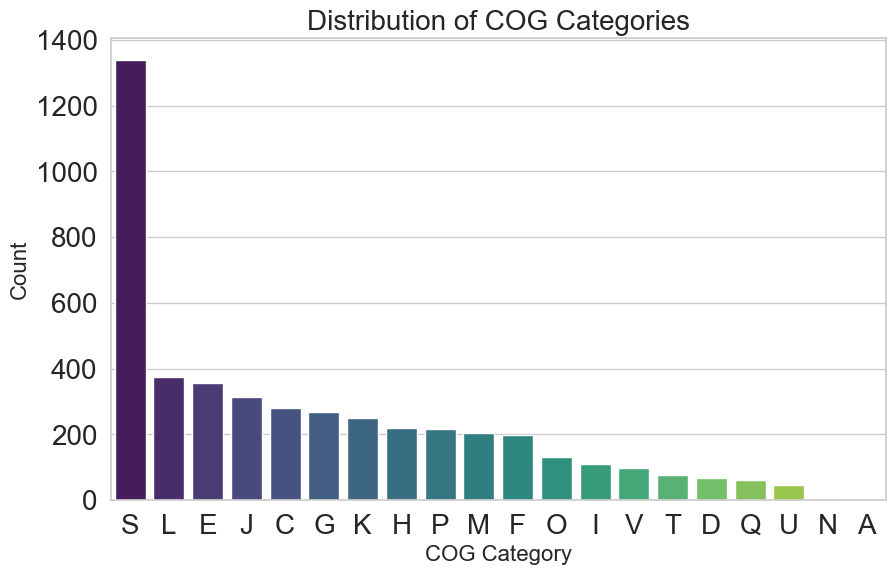

In [9]:
# Visualizing Data
sns.set(style="whitegrid")

# Creating a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='COG_category', y='count', data=cog_counts_df, palette='viridis')

plt.title('Distribution of COG Categories', fontsize = 20)
plt.xlabel('COG Category', fontsize = 16)
plt.ylabel('Count', fontsize = 16)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Save the plot to a file
plt.savefig('COG_category_distribution_single.png', dpi=300)

plt.show()

plt.close()